In [1]:
%%capture
!pip install transformers

In [1]:
import pandas as pd
import torch
import numpy as np
import re
import string
from sklearn import preprocessing


from transformers import BertTokenizer, BertModel
from torch import nn
from torch import optim
from torch.optim import Adam
from tqdm import tqdm

In [2]:
datapath = 'bbc-text.csv'
df = pd.read_csv(datapath)
df.head()

,category,text,label
0,tech,tv future in the hands of viewers with home th...,3
1,business,worldcom boss left books alone former worldc...,0
2,sport,tigers wary of farrell gamble leicester say ...,2
3,sport,yeading face newcastle in fa cup premiership s...,2
4,entertainment,ocean s twelve raids box office ocean s twelve...,1


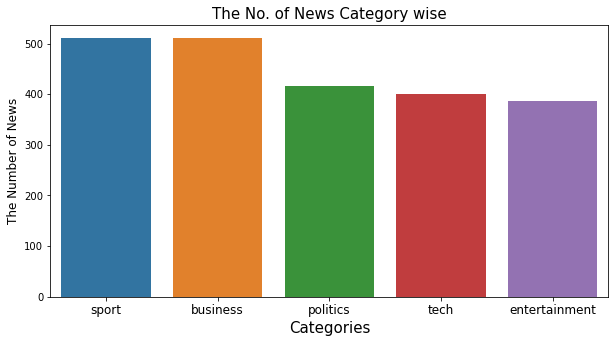

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

category_counts = df['category'].value_counts()
categories = category_counts.index

fig = plt.figure(figsize = (10,5))
ax = fig.add_subplot(111)
sns.barplot(x = category_counts.index , y = category_counts)
plt.xlabel('Categories', size = 15)
plt.ylabel('The Number of News', size= 12)
plt.xticks(size = 12)

plt.title("The No. of News Category wise" , size = 15)
plt.show()

In [5]:
tokenizer = BertTokenizer.from_pretrained('bert-base-cased')
labels = {'business':0,
          'entertainment':1,
          'sport':2,
          'tech':3,
          'politics':4
          }
train_acc = []
train_loss = []
val_acc = []
val_loss = []


class Dataset(torch.utils.data.Dataset):

    def __init__(self, df):

        self.labels = [labels[label] for label in df['category']]
        self.texts = [tokenizer(text, 
                               padding='max_length', max_length = 512, truncation=True,
                                return_tensors="pt") for text in df['text']]

    def classes(self):
        return self.labels

    def __len__(self):
        return len(self.labels)

    def get_batch_labels(self, idx):
        # Fetch a batch of labels
        return np.array(self.labels[idx])

    def get_batch_texts(self, idx):
        # Fetch a batch of inputs
        return self.texts[idx]

    def __getitem__(self, idx):

        batch_texts = self.get_batch_texts(idx)
        batch_y = self.get_batch_labels(idx)

        return batch_texts, batch_y

In [6]:
class BertClassifier(nn.Module):

    def __init__(self, dropout=0.5):

        super(BertClassifier, self).__init__()

        self.bert = BertModel.from_pretrained('bert-base-cased')
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(768, 5)
        self.relu = nn.ReLU()

    def forward(self, input_id, mask):

        _, pooled_output = self.bert(input_ids= input_id, attention_mask=mask,return_dict=False)
        dropout_output = self.dropout(pooled_output)
        linear_output = self.linear(dropout_output)
        final_layer = self.relu(linear_output)

        return final_layer

In [7]:
def train(model, train_data, val_data, learning_rate, epochs):
    
    train, val = Dataset(train_data), Dataset(val_data)

    train_dataloader = torch.utils.data.DataLoader(train, batch_size=2, shuffle=True)
    val_dataloader = torch.utils.data.DataLoader(val, batch_size=2)

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    criterion = nn.CrossEntropyLoss()
    optimizer = Adam(model.parameters(), lr= learning_rate)

    if use_cuda:

            model = model.cuda()
            criterion = criterion.cuda()

    for epoch_num in range(epochs):

            total_acc_train = 0
            total_loss_train = 0

            for train_input, train_label in tqdm(train_dataloader):

                train_label = train_label.to(device)
                mask = train_input['attention_mask'].to(device)
                input_id = train_input['input_ids'].squeeze(1).to(device)

                output = model(input_id, mask)
                
                batch_loss = criterion(output, train_label.long())
                total_loss_train += batch_loss.item()
                train_loss.append(total_loss_train / len(train_data))
                
                acc = (output.argmax(dim=1) == train_label).sum().item()
                total_acc_train += acc
                train_acc.append(total_acc_train / len(train_data))

                model.zero_grad()
                batch_loss.backward()
                optimizer.step()
            
            total_acc_val = 0
            total_loss_val = 0

            with torch.no_grad():

                for val_input, val_label in val_dataloader:

                    val_label = val_label.to(device)
                    mask = val_input['attention_mask'].to(device)
                    input_id = val_input['input_ids'].squeeze(1).to(device)

                    output = model(input_id, mask)

                    batch_loss = criterion(output, val_label.long())
                    total_loss_val += batch_loss.item()
                    val_loss.append(total_loss_val / len(val_data))
                    
                    acc = (output.argmax(dim=1) == val_label).sum().item()
                    total_acc_val += acc
                    val_acc.append(total_acc_val / len(val_data))
            
            print(
                f'Epochs: {epoch_num + 1} | Train Loss: {total_loss_train / len(train_data): .3f} | Train Accuracy: {total_acc_train / len(train_data): .3f} | Val Loss: {total_loss_val / len(val_data): .3f} | Val Accuracy: {total_acc_val / len(val_data): .3f}')
                  

In [8]:
def evaluate(model, test_data):

    test = Dataset(test_data)

    test_dataloader = torch.utils.data.DataLoader(test, batch_size=2)

    use_cuda = torch.cuda.is_available()
    device = torch.device("cuda" if use_cuda else "cpu")

    if use_cuda:

        model = model.cuda()

    total_acc_test = 0
    with torch.no_grad():

        for test_input, test_label in test_dataloader:

              test_label = test_label.to(device)
              mask = test_input['attention_mask'].to(device)
              input_id = test_input['input_ids'].squeeze(1).to(device)

              output = model(input_id, mask)

              acc = (output.argmax(dim=1) == test_label).sum().item()
              total_acc_test += acc
    
    print(f'Test Accuracy: {total_acc_test / len(test_data): .3f}')

In [9]:
np.random.seed(112)
df_train, df_val, df_test = np.split(df.sample(frac=1, random_state=42), 
                                     [int(.8*len(df)), int(.9*len(df))])

print(len(df_train),len(df_val), len(df_test))

1780 222 223


In [9]:
EPOCHS = 2
model = BertClassifier()
LR = 1e-6
              
train(model, df_train, df_val, LR, EPOCHS)

Some weights of the model checkpoint at bert-base-cased were not used when initializing BertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.dense.weight']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
100%|██████████| 890/890 [39:49<00:00,  2.68s/it]


Epochs: 1 | Train Loss:  0.716 | Train Accuracy:  0.415 | Val Loss:  0.579 | Val Accuracy:  0.653


100%|██████████| 890/890 [41:49<00:00,  2.82s/it]


Epochs: 2 | Train Loss:  0.404 | Train Accuracy:  0.834 | Val Loss:  0.260 | Val Accuracy:  0.950


In [10]:
torch.save(model, 'C:/Users/admin/finalbert.pt')

In [11]:
EPOCHS = 2
model = torch.load('C:/Users/admin/finalbert.pt')
LR = 1e-6
              
train(model, df_train, df_val, LR, EPOCHS)

100%|██████████| 890/890 [43:39<00:00,  2.94s/it]


Epochs: 1 | Train Loss:  0.216 | Train Accuracy:  0.946 | Val Loss:  0.159 | Val Accuracy:  0.982


100%|██████████| 890/890 [44:07<00:00,  2.97s/it]


Epochs: 2 | Train Loss:  0.137 | Train Accuracy:  0.971 | Val Loss:  0.090 | Val Accuracy:  1.000


 17%|█▋        | 151/890 [07:35<37:09,  3.02s/it]


KeyboardInterrupt: 

In [12]:
print(train_acc)

[0.0005617977528089888, 0.0005617977528089888, 0.0005617977528089888, 0.0005617977528089888, 0.0011235955056179776, 0.0011235955056179776, 0.0011235955056179776, 0.0011235955056179776, 0.0011235955056179776, 0.0011235955056179776, 0.0016853932584269663, 0.0016853932584269663, 0.0016853932584269663, 0.0022471910112359553, 0.0022471910112359553, 0.0022471910112359553, 0.0022471910112359553, 0.0022471910112359553, 0.0028089887640449437, 0.0028089887640449437, 0.0033707865168539327, 0.0033707865168539327, 0.0033707865168539327, 0.0033707865168539327, 0.0033707865168539327, 0.0033707865168539327, 0.0033707865168539327, 0.0033707865168539327, 0.003932584269662922, 0.003932584269662922, 0.0050561797752808986, 0.0050561797752808986, 0.0050561797752808986, 0.0050561797752808986, 0.0056179775280898875, 0.0056179775280898875, 0.0056179775280898875, 0.0056179775280898875, 0.006179775280898876, 0.006179775280898876, 0.006741573033707865, 0.006741573033707865, 0.007303370786516854, 0.007865168539325

In [14]:
print(val_acc)

[0.0045045045045045045, 0.009009009009009009, 0.013513513513513514, 0.02252252252252252, 0.02702702702702703, 0.03153153153153153, 0.036036036036036036, 0.04054054054054054, 0.04954954954954955, 0.05855855855855856, 0.05855855855855856, 0.06756756756756757, 0.07207207207207207, 0.07207207207207207, 0.08108108108108109, 0.08558558558558559, 0.08558558558558559, 0.09009009009009009, 0.09009009009009009, 0.0945945945945946, 0.0990990990990991, 0.10810810810810811, 0.11711711711711711, 0.12612612612612611, 0.13513513513513514, 0.14414414414414414, 0.14864864864864866, 0.14864864864864866, 0.15765765765765766, 0.16666666666666666, 0.17117117117117117, 0.17117117117117117, 0.17117117117117117, 0.18018018018018017, 0.18468468468468469, 0.1891891891891892, 0.1981981981981982, 0.1981981981981982, 0.2072072072072072, 0.21621621621621623, 0.22072072072072071, 0.22522522522522523, 0.23423423423423423, 0.24324324324324326, 0.25225225225225223, 0.25675675675675674, 0.26126126126126126, 0.26576576576

In [12]:
evaluate(model, df_test)

Test Accuracy:  0.978


In [25]:
torch.save(model, 'C:/Users/admin/finalbert.pt')

In [16]:
optimizer = torch.optim.RMSprop(model.parameters(), lr=LR)
torch.save({'epoch': EPOCHS,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': 0.192}, 
	    'C:/Users/admin/bertmodel.pth')


In [20]:
torch.save(model.state_dict(), 'C:/Users/admin/bertmodel1.pth')

In [21]:
torch.save(model, 'C:/Users/admin/bertmodelentire.pt')

In [17]:
model = BertClassifier()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)


checkpoint = torch.load('C:/Users/admin/bertmodel.pth')
model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
epoch = checkpoint['epoch']
loss = checkpoint['loss']


Some weights of the model checkpoint at bert-base-cased were not used when initializing BertModel: ['cls.predictions.transform.dense.weight', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.seq_relationship.weight', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.decoder.weight', 'cls.seq_relationship.bias']
- This IS expected if you are initializing BertModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [18]:
EPOCHS = 2
model = torch.load('C:/Users/admin/bertmodelentire.pt')
LR = 1e-6
              
train(model, df_train, df_val, LR, EPOCHS)

100%|██████████| 890/890 [41:24<00:00,  2.79s/it]


Epochs: 1 | Train Loss:  0.140 | Train Accuracy:  0.975 | Val Loss:  0.088 | Val Accuracy:  0.991


100%|██████████| 890/890 [41:27<00:00,  2.80s/it]


Epochs: 2 | Train Loss:  0.074 | Train Accuracy:  0.982 | Val Loss:  0.049 | Val Accuracy:  0.995


In [19]:
torch.save(model, 'C:/Users/admin/bertmodelentire.pt')

In [20]:
EPOCHS = 1
model = torch.load('C:/Users/admin/bertmodelentire.pt')
LR = 1e-6
              
train(model, df_train, df_val, LR, EPOCHS)

100%|██████████| 890/890 [42:34<00:00,  2.87s/it]


Epochs: 1 | Train Loss:  0.039 | Train Accuracy:  0.992 | Val Loss:  0.040 | Val Accuracy:  0.991


In [21]:
torch.save(model, 'C:/Users/admin/bertmodelentire.pt')

In [22]:
model = torch.load('C:/Users/admin/bertmodelentire.pt')

In [23]:
evaluate(model, df_test)

Test Accuracy:  0.991


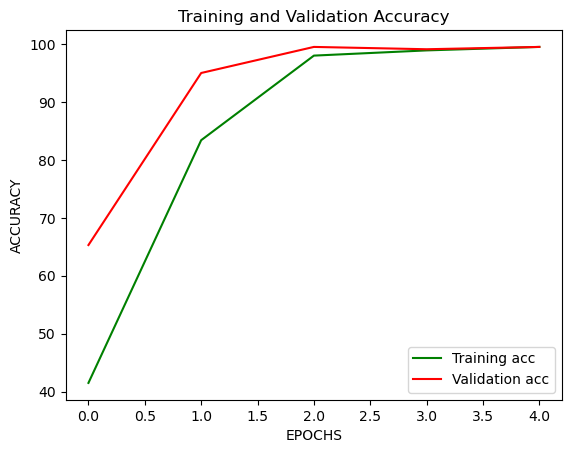

In [4]:
import matplotlib.pyplot as plt

plt.style.use('default')

tacc = [41.5, 83.4, 98.0, 98.9, 99.5]
vacc = [65.3, 95.0, 99.5, 99.1, 99.5]
# plt.plot(train_acc)
plt.plot(tacc, 'g', label='Training acc')
plt.plot(vacc, 'r', label='Validation acc')
plt.title('Training and Validation Accuracy')
plt.legend(loc='lower right')

plt.xlabel('EPOCHS')

plt.ylabel('ACCURACY')

# ax = plt.gca()

# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
# ax.spines['left'].set_bounds(0, 75)

# plt.xticks(list(range(0, 5)))

plt.show()


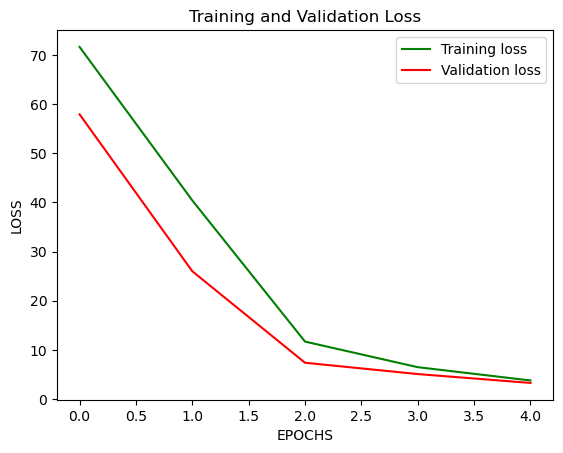

In [3]:
plt.style.use('default')

tloss = [71.6, 40.4, 11.7, 6.5, 3.8]
vloss = [57.9, 26.0, 7.4, 5.1, 3.3]
# plt.plot(train_loss)
plt.plot(tloss, 'g', label='Training loss')
plt.plot(vloss, 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.xlabel('EPOCHS')
plt.ylabel('LOSS')

# ax = plt.gca()

# ax.spines['right'].set_visible(False)
# ax.spines['top'].set_visible(False)
# ax.spines['left'].set_bounds(0, 75)

# plt.xticks(list(range(0, 5)))
plt.show()


In [10]:
model = torch.load('C:/Users/thomb/finalbert.pt')

In [12]:
from torch.optim import Adam
from tqdm import tqdm
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained('bert-base-cased')

ex2 = "california sets fines for spyware the makers of computer programs that secretly spy on what people do with their home pcs could face hefty fines in california.  from 1 january  a new law is being introduced to protect computer users from software known as spyware. the legislation  which was approved by governor arnold schwarzenegger  is designed to safeguard people from hackers and help protect their personal information. spyware is considered by computer experts to be one of the biggest nuisance and security threats facing pc users in the coming year. the software buries itself in computers and can collect a wide range of information. at its worst  it has the ability to hijack personal data  like passwords  login details and credit card numbers. the programs are so sophisticated they change frequently and become impossible to eradicate.  one form of spyware called adware has the ability to collect information on a computer user s web-surfing. it can result in people being bombarded with pop-up ads that are hard to close. in washington  congress has been debating four anti-spyware bills  but california is a step ahead. the state s consumer protection against spyware act bans the installation of software that takes control of another computer. it also requires companies and websites to disclose whether their systems will install spyware. consumers are able to seek up to $1 000 in damages if they think they have fallen victim to the intrusive software. the new law marks a continuing trend in california towards tougher privacy rights. a recent survey by earthlink and webroot found that 90% of pcs are infested with the surreptitious software and that  on average  each one is harbouring 28 separate spyware programs. currently users wanting protection from spyware have turned to free programs such as spybot and ad-aware."
bert_input = tokenizer(ex2,padding='max_length', max_length = 512, 
                       truncation=True, return_tensors="pt")
device = torch.device("cpu")

inids = bert_input['input_ids'].squeeze(1).to(device)
attmask = bert_input['attention_mask'].to(device)

print(inids)
print(attmask)
model = torch.load('C:/Users/thomb/bertmodelentire.pt')
output = model(inids,attmask)
index = torch.argmax(output)
lab = ['Business','Entertainment','Sports','Technology','Politics']
print(output,lab[index])

tensor([[  101, 11019,  2646, 14467,  4558,  1465,  3741, 25488,  1111, 10669,
          7109,  1103, 12525,  1104,  2775,  2648,  1115, 10173, 10669,  1113,
          1184,  1234,  1202,  1114,  1147,  1313,   185,  6063,  1180,  1339,
          1119, 27944, 25488,  1107, 11019,  2646, 14467,  4558,  1465,   119,
          1121,   122,   179, 19762,  3113,   170,  1207,  1644,  1110,  1217,
          2234,  1106,  3244,  2775,  4713,  1121,  3594,  1227,  1112, 10669,
          7109,   119,  1103,  5626,  1134,  1108,  4092,  1118,  4066,   170,
         11791,  5253,   188,  1732,  7200, 10947, 12606,  2895,  1110,  2011,
          1106,  2914, 12188,  1234,  1121,  5871, 24138,  1105,  1494,  3244,
          1147,  2357,  1869,   119, 10669,  7109,  1110,  1737,  1118,  2775,
          8724,  1106,  1129,  1141,  1104,  1103,  4583,   183,  6592, 27346,
          1105,  2699,  8657,  4749,   185,  1665,  4713,  1107,  1103,  1909,
          1214,   119,  1103,  3594,   171, 19363,  